# Building Backtesting Framework and Performance Measurements

The goal of this notebook is to understand how a backtest and PnL curve is generated

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Paths and Global Variables

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")
zone_path = os.path.join(data_path, "ZoneImputedFirstRateData")

In [3]:
day_renamer = {
    "day_after"   : "Day After",
    "day_before"  : "Day Before",
    "post_meeting": "Post Meeting",
    "pre_meeting" : "Pre Meeting"}

zone_renamer = {
    "zone1": "Day Before",
    "zone2": "Before Meeting",
    "zone3": "After Meeting",
    "zone4": "Day After"}

replacer = {**day_renamer, **zone_renamer}

# Calculating the backtest

One of the problems of generating PnL curves is the following
1. non-continuous times
2. each contract trading at different durations / vols and thus not normalized

In [4]:
path    = os.path.join(data_path, r"ZoneImputedFirstRateData")
df_zone = (pd
    .read_parquet(path = path)
    .loc[lambda x: x.ticker != "ZQ"]
    .set_index("date")
    [["meeting_id", "ticker", "contract", "impute_open", "zone", "name"]])

In [5]:
df_pnl = (df_zone
    .groupby(["meeting_id", "ticker", "contract", "zone", "name"])
    .apply(lambda x: x.sort_index().impute_open.diff())
    .reset_index())

Text(0.5, 1.0, 'Cumulative PnL of Volatility Targeted PnLs Hedged Perfectly and Minutely\nUsing 10d EWMA')

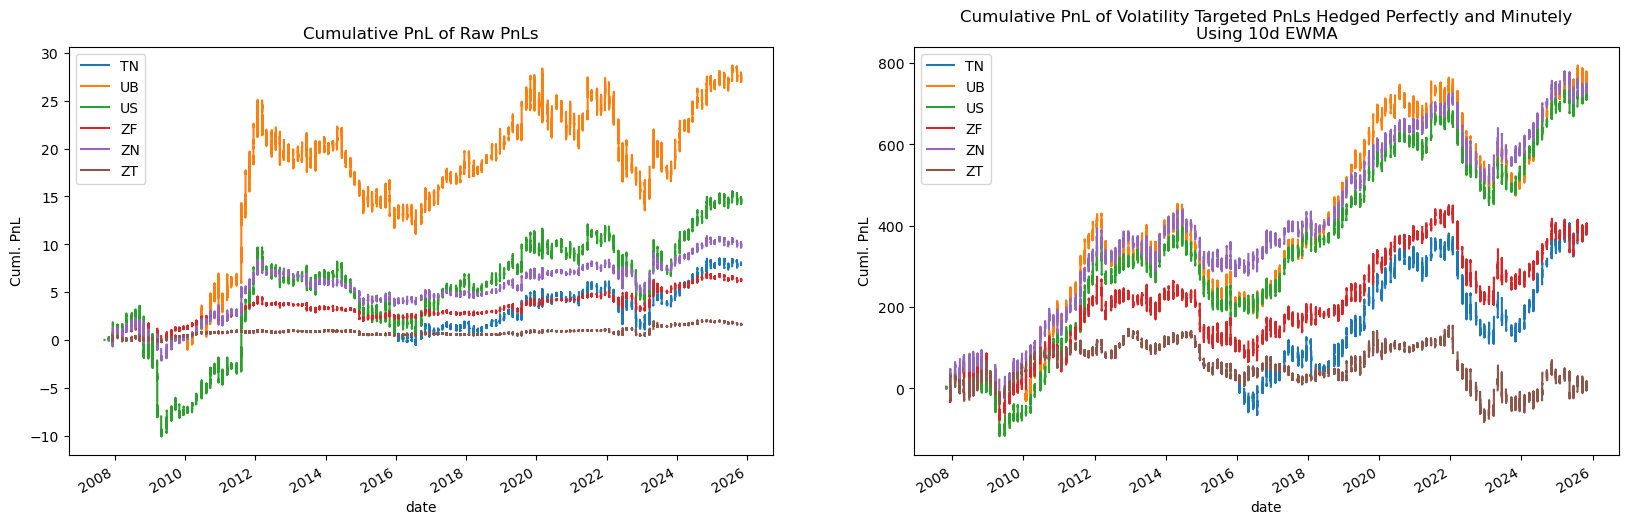

In [6]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_pnl
    .rename(columns = {"ticker": ""})
    .pivot(index = "date", columns = "", values = "impute_open")
    .cumsum()
    .plot(
        ax = axes[0]))

(df_pnl
    .rename(columns = {"ticker": ""})
    .pivot(index = "date", columns = "", values = "impute_open")
    .apply(lambda x: x / x.ewm(span = 10, adjust = False).std())
    .apply(lambda x: np.where(np.abs(x) > 50, np.nan, x))
    .cumsum()
    .plot(
        ax = axes[1]))

for ax in axes.flatten(): 
    ax.set_ylabel("Cuml. PnL")

axes[0].set_title("Cumulative PnL of Raw PnLs")
axes[1].set_title("Cumulative PnL of Volatility Targeted PnLs Hedged Perfectly and Minutely\nUsing 10d EWMA")

The PnLs need some sort of volatility targeting to noramlize the returns when we make the portfolio. On the other hand its not possible to hedge, and perfectly as well, at the minutely level. Therefore we need a volatility targeting tool that does the following
1. Calcluates a hedge value per every trade
2. Keeps the PnL in line with the initial hedge values
3. Also use the prior price action data (which isn't present in the trading zones) data, and thus properly hedge. 

# Finding the optimal volatility calculation

Ideally we want to find a volatility measurement that accurately sets a volatility target. Using the historical data, there are two options 
1. We can use the prior day's volatility calculation which comes from the data
2. We can use the prior event's volatility calculation

At this moment there are arguments for either since the prior day's volatility may capture the macro economic backdrop greater than the prior event, yet the whole point of this repo is to trade a repeatable pattern around FOMC announcements. Therefore we'll test both and see which is better. 

In [18]:
path         = os.path.join(data_path, "Volatilities", "CombinedVolEstimators.parquet")
df_vol_panel = (pd.read_parquet(path = path))

In [56]:
df_day_before = (df_vol_panel
    .loc[lambda x: x.name == "day_before"]
    .assign(
        lzone_vol = lambda x: np.log(x.lzone_vol),
        cur_vol   = lambda x: np.log(x.cur_vol),
        lday_vol  = lambda x: np.log(x.lday_vol)))

When comparing the log volatilities estimators there is a strong linear relationship. Below is a plot showing the relationship between the prior day's volatility (for the corresopnding zone) and the prior event's volatility (prior meeting) volatility. 

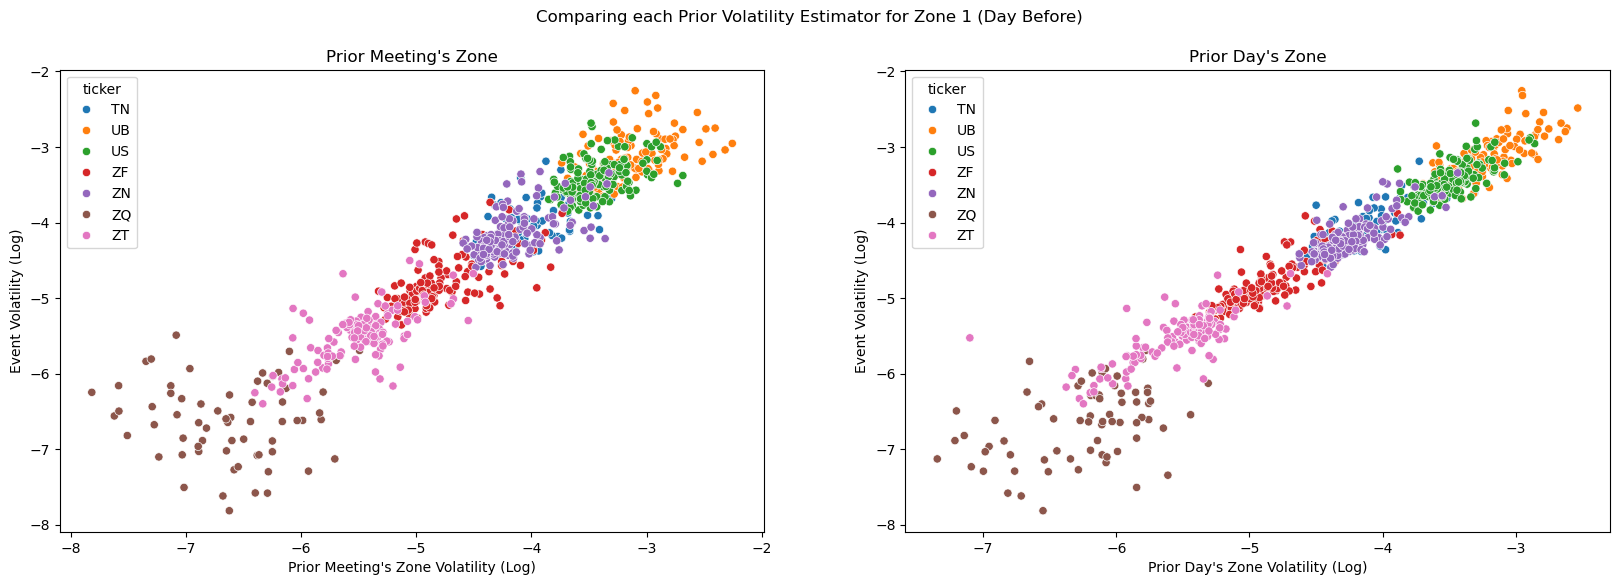

In [57]:
fig, axes   = plt.subplots(ncols = 2, figsize = (20,6))
vol_renamer = {
    "lzone_vol": "Prior Meeting's Zone", 
    "lday_vol" : "Prior Day's Zone"}

for i, vol in enumerate(vol_renamer.keys()):

    sns.scatterplot(
        ax   = axes[i],
        data = df_day_before,
        x    = vol,
        y    = "cur_vol",
        hue  = "ticker")

    axes[i].set_ylabel("Event Volatility (Log)")
    axes[i].set_xlabel(vol_renamer[vol] + " Volatility (Log)")
    axes[i].set_title(vol_renamer[vol])

fig.suptitle("Comparing each Prior Volatility Estimator for Zone 1 (Day Before)")
plt.show()

In [62]:
df_tn_vol = (df_vol_panel
    .loc[lambda x: x.ticker == x.ticker.min()]
    [["name", "lzone_vol", "cur_vol", "lday_vol"]]
    .set_index("name")
    .apply(lambda x: np.log(x))
    .reset_index()
    .replace(replacer))

It appears that the relationship is not strong when comparing them across different zones. This implies that different periods around FOMC announcements have non uniform volatility structures. Notice on the left hand of the plot the prior meeting times appears to have a more linear relationship than the prior day's. This shows that it was right to be cautious about using the prior day's volatility. 

Text(0.5, 0.98, 'Comparing each Prior Volatility Estimator for TN Futures')

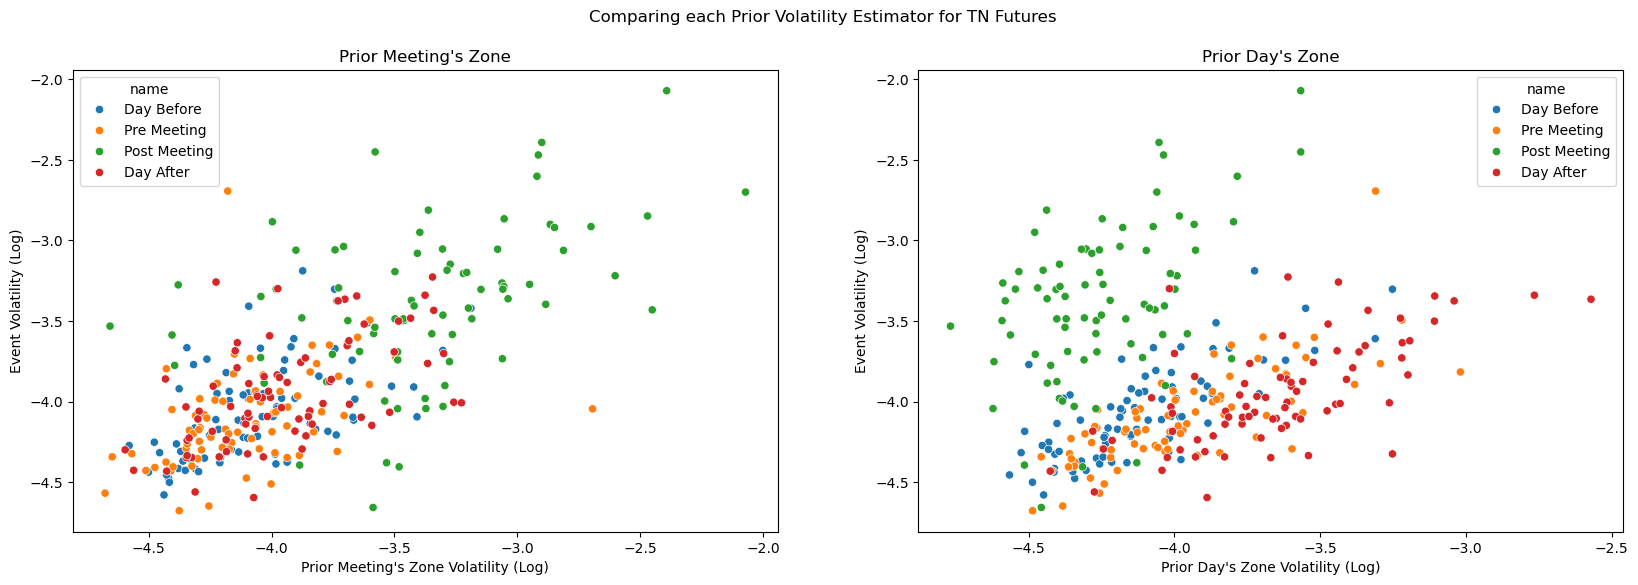

In [64]:
fig, axes   = plt.subplots(ncols = 2, figsize = (20,6))
vol_renamer = {
    "lzone_vol": "Prior Meeting's Zone", 
    "lday_vol" : "Prior Day's Zone"}

for i, vol in enumerate(vol_renamer.keys()):

    sns.scatterplot(
        ax   = axes[i],
        data = df_tn_vol,
        x    = vol,
        y    = "cur_vol",
        hue  = "name")

    axes[i].set_ylabel("Event Volatility (Log)")
    axes[i].set_xlabel(vol_renamer[vol] + " Volatility (Log)")
    axes[i].set_title(vol_renamer[vol])

fig.suptitle("Comparing each Prior Volatility Estimator for TN Futures")

Before setting up the first model for testing start by deciding if we have enough data to begin. Below is a table its reasonable but we have to consider that a full out-of-sample model diminishes the data size. 

In [75]:
(df_vol_panel
    [["ticker", "name", "lag_contract"]]
    .groupby(["ticker", "name"])
    .agg("count")
    .reset_index()
    .rename(columns = {"name": ""})
    .pivot(index = "ticker", columns = "", values = "lag_contract")
    .rename(columns = replacer))

,Day After,Day Before,Post Meeting,Pre Meeting
ticker,,,,
TN,77,78,77,78
UB,126,126,126,126
US,145,145,144,144
ZF,142,141,140,142
ZN,143,143,142,142
ZQ,108,108,97,109
ZT,143,143,143,142


When comparing raw correlations it appears that the the prior day volatility is a better estimator

In [95]:
df_vol_corr = (df_vol_panel
    [["ticker", "name", "cur_vol", "lzone_vol", "lday_vol"]]
    .melt(id_vars = ["ticker", "name", "cur_vol"])
    .groupby(["ticker", "name", "variable"])
    .agg("corr")
    .reset_index()
    .drop(columns = ["level_3", "cur_vol"])
    .loc[lambda x: x.value != 1]
    .pivot(index = ["ticker", "variable"], columns = "name", values = "value"))

display(df_vol_corr)

name              day_after  day_before  post_meeting  pre_meeting
ticker variable                                                   
TN     lday_vol    0.633238    0.745276      0.592879     0.643383
       lzone_vol   0.502237    0.481407      0.518249     0.212476
UB     lday_vol    0.627908    0.731814      0.511992     0.560531
       lzone_vol   0.475043    0.418571      0.407737     0.250602
US     lday_vol    0.377306    0.289004      0.426415     0.522958
       lzone_vol   0.331088    0.413897      0.256174     0.198990
ZF     lday_vol    0.463760    0.787313      0.591029     0.684044
       lzone_vol   0.386387    0.619376      0.475947     0.304388
ZN     lday_vol    0.378734    0.764863      0.533474     0.626716
       lzone_vol   0.366195    0.534727      0.436068     0.298285
ZQ     lday_vol    0.587545    0.246055      0.311394     0.427576
       lzone_vol   0.258927    0.338070      0.350336     0.138777
ZT     lday_vol    0.670684    0.763389      0.305442     0.748744
       lzone_vol   0.588373    0.614421      0.574599     0.396211

The Prior Day volatility estimate adds a reasonable amount of extra correlation for almost all scenarios

In [102]:
(df_vol_corr
    .reset_index()
    .melt(id_vars = ["ticker", "variable"])
    .pivot(index = ["ticker", "name"], columns = "variable", values = "value")
    .assign(extra_corr = lambda x: x.lday_vol - x.lzone_vol)
    .reset_index()
    .pivot(index = "ticker", columns = "name", values = "extra_corr"))

name,day_after,day_before,post_meeting,pre_meeting
ticker,,,,
TN,0.131001,0.263869,0.074630,0.430907
UB,0.152865,0.313243,0.104255,0.309930
US,0.046218,-0.124893,0.170241,0.323968
ZF,0.077373,0.167937,0.115082,0.379656
ZN,0.012538,0.230136,0.097406,0.328431
ZQ,0.328618,-0.092015,-0.038942,0.288799
ZT,0.082310,0.148968,-0.269157,0.352533


There is reason to believe that adding the Lagged Perior Volatility since the correlation between the two exoegenous factors is quite low. 

In [94]:
(df_vol_panel
    [["ticker", "name", "lzone_vol", "lday_vol"]]
    .groupby(["ticker", "name"])
    .agg("corr")
    .loc[lambda x: x.lday_vol != 1]
    .reset_index()
    .pivot(index = "ticker", columns = "name", values = "lday_vol"))

name,day_after,day_before,post_meeting,pre_meeting
ticker,,,,
TN,0.429402,0.537401,0.441947,0.311838
UB,0.383314,0.598621,0.335469,0.268674
US,0.220396,0.174238,0.250763,0.250457
ZF,0.390400,0.598899,0.374510,0.380270
ZN,0.367540,0.592225,0.361849,0.362061
ZQ,0.156091,-0.018746,0.181297,0.113133
ZT,0.464224,0.567351,0.148377,0.517937
